## Term Paper - Winter Semester 25/26 Submission

#### **Research Topic: Is Attention All You Need in Low-Resource Settings? An empirical study of self attention integrated with BiLSTM vs Transformers for a low resource language; Swahili.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
holdout_train = pd.read_csv("Swahili_News_Train.csv")
holdout_test = pd.read_csv("Swahili_News_Test.csv")

print(f"Validate train column names: {holdout_train.columns},\nValidate test column names: {holdout_test.columns}")

Validate train column names: Index(['id', 'content', 'category'], dtype='object'),
Validate test column names: Index(['swahili_id', 'content'], dtype='object')


In [3]:
swahili_news = pd.read_csv("SwahiliNewsClassificationDataset.csv")
swahili_news.head()

,id,content,category
0,SW4670,"Bodi ya Utalii Tanzania (TTB) imesema, itafan...",uchumi
1,SW30826,"PENDO FUNDISHA-MBEYA RAIS Dk. John Magufuri, ...",kitaifa
2,SW29725,Mwandishi Wetu -Singida BENKI ya NMB imetoa ms...,uchumi
3,SW20901,"TIMU ya taifa ya Tanzania, Serengeti Boys jan...",michezo
4,SW12560,Na AGATHA CHARLES – DAR ES SALAAM ALIYEKUWA K...,kitaifa


In [4]:
holdout_train["content"] = holdout_train["content"].apply(lambda x: str(x.lower().rstrip().lstrip()))
swahili_news["content"] = swahili_news["content"].apply(lambda x: str(x.lower().rstrip().lstrip()))
swahili_news["category"] = swahili_news["category"].apply(lambda x: str(x.lower().rstrip().lstrip()))
holdout_train["category"] = holdout_train["category"].apply(lambda x: str(x.lower().rstrip().lstrip()))

In [5]:
print(
    f"Training set has {swahili_news.shape[0]} rows while validation/developer set has {holdout_train.shape[0]} rows."
    )

Training set has 23268 rows while validation/developer set has 5151 rows.


In [6]:
print(
    f"Categories in training but missing in validation: {set(swahili_news["category"].str.lower().unique()) - set(holdout_train["category"].str.lower().unique())}"
    )

Categories in training but missing in validation: {'afya', 'uchumi'}


In [7]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].str.lower().unique()) - set(swahili_news["category"].str.lower().unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [8]:
print(
    f"Categories in validation but missing in training: {set(holdout_train["category"].unique()) - set(swahili_news["category"].unique())}"
    )

Categories in validation but missing in training: {'biashara'}


In [9]:
print(
    f"Categories is training data: {swahili_news["category"].str.lower().unique()}.\nCategories in validation set: {holdout_train["category"].str.lower().unique()}"
    )

Categories is training data: ['uchumi' 'kitaifa' 'michezo' 'kimataifa' 'burudani' 'afya'].
Categories in validation set: ['kitaifa' 'biashara' 'michezo' 'kimataifa' 'burudani']


In [10]:
set(
    holdout_train["category"].str.lower().unique()
    ) & set(
        swahili_news["category"].str.lower().unique()
        )

{'burudani', 'kimataifa', 'kitaifa', 'michezo'}

In [11]:
swahili_news["category"].value_counts()

category
kitaifa      10242
michezo       6004
burudani      2229
uchumi        2028
kimataifa     1906
afya           859
Name: count, dtype: int64

In [12]:
holdout_train["category"].value_counts()

category
kitaifa      2000
michezo      1720
biashara     1360
kimataifa      54
burudani       17
Name: count, dtype: int64

<Axes: xlabel='category', ylabel='count'>

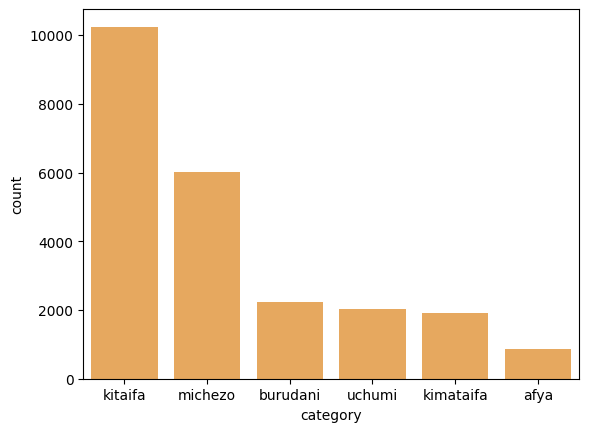

In [13]:
sns.countplot(
    x="category",
    data=swahili_news,
    color="#fdaa48",
    order=swahili_news["category"].value_counts().index
    )

<Axes: xlabel='category', ylabel='count'>

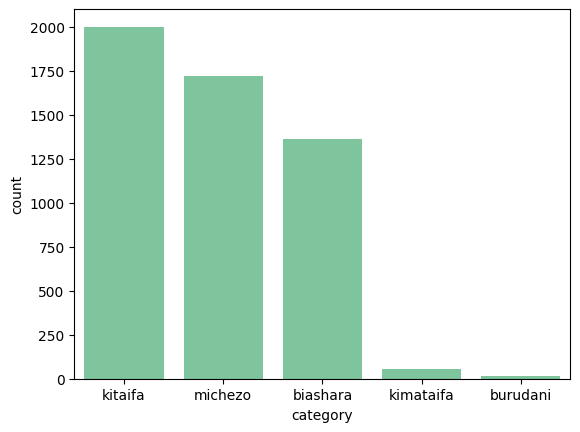

In [14]:
sns.countplot(
    x="category",
    data=holdout_train,
    color="#72d09c",
    order=holdout_train["category"].value_counts().index
    )

In [15]:
holdout_train[holdout_train["content"] == str(swahili_news.loc[1, "content"].lower().rstrip().lstrip())]

,id,content,category


In [21]:
swahili_news.loc[23258, "content"].lower().rstrip().lstrip()

'na ramadhan libenanga-morogoro \nwafugaji wilayani mvomero mkoa wa morogoro, wamesema wamekuwa wakitumia fedha nyingi kununua mihtasari ya vikao vya vijiji ili kuzionyesha mamlaka mbalimbali jinsi walivyoruhusiwa kumiliki ardhi waliyonayo.\nhayo yalielezwa jana na mchungaji joseph sepuke, alipokuwa akizungumza kwenye mkutano wa hadhara katika kijiji cha kibaoni wilayani mvomero. \n“wamasai wanapata mihtasari ya kijiji kwa gharama kubwa na viongozi hawa hawa wa vijiji ndio wanaowauzia hii mihtasari ili waweze kumilikishwa maeneo. \n“kwa hiyo, tunaomba gharama za mihtasari hiyo zipunguzwe ili tuweze kuzipata kwa urahisi zaidi,” alisema sepuke.\nawali, akizungumza katika mkutano huo, mjumbe wa serikali ya kijiji cha kibaoni, fabian beatus, alisema kijiji chao kimegundua kuna baadhi ya wananchi walioghushi mihtasari ya vijiji na kufanikiwa kupata ardhi. \n“kuna watu wameghushi mihtasari kwa sababu sharti kuu linalomwezesha mwananchi kumiliki ardhi ni kuwa na muhtasari unaoonyesha vikao ha

In [17]:
set(holdout_train["id"].unique().tolist()) - set(swahili_news["id"].unique().tolist())

{'SW1359',
 'SW5139',
 'SW5198',
 'SW760',
 'SW350',
 'SW1923',
 'SW3162',
 'SW3069',
 'SW1093',
 'SW3384',
 'SW739',
 'SW6224',
 'SW1616',
 'SW217',
 'SW2395',
 'SW5418',
 'SW2723',
 'SW5478',
 'SW4192',
 'SW2671',
 'SW5925',
 'SW3298',
 'SW4867',
 'SW3039',
 'SW1699',
 'SW976',
 'SW4926',
 'SW430',
 'SW3916',
 'SW3978',
 'SW4406',
 'SW1320',
 'SW4633',
 'SW3242',
 'SW1931',
 'SW6415',
 'SW4704',
 'SW5031',
 'SW2471',
 'SW842',
 'SW2532',
 'SW3573',
 'SW3250',
 'SW1794',
 'SW4197',
 'SW1195',
 'SW3127',
 'SW4000',
 'SW6173',
 'SW5567',
 'SW3089',
 'SW3360',
 'SW6353',
 'SW6376',
 'SW5943',
 'SW997',
 'SW4479',
 'SW5469',
 'SW2354',
 'SW5979',
 'SW914',
 'SW5329',
 'SW6379',
 'SW1307',
 'SW424',
 'SW4885',
 'SW1772',
 'SW352',
 'SW5339',
 'SW2253',
 'SW5358',
 'SW4088',
 'SW3125',
 'SW6140',
 'SW5814',
 'SW412',
 'SW256',
 'SW6226',
 'SW4941',
 'SW2312',
 'SW741',
 'SW2715',
 'SW5713',
 'SW1029',
 'SW4329',
 'SW2130',
 'SW381',
 'SW4691',
 'SW5009',
 'SW1232',
 'SW5484',
 'SW3126',
 'S

In [18]:
set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())

{'SW1960',
 'SW2252',
 'SW734',
 'SW4233',
 'SW2010',
 'SW2753',
 'SW2505',
 'SW5089',
 'SW4681',
 'SW2788',
 'SW452',
 'SW1822',
 'SW725',
 'SW1392',
 'SW4168',
 'SW67',
 'SW4029',
 'SW665',
 'SW366',
 'SW1892',
 'SW265',
 'SW4645',
 'SW1116',
 'SW5869',
 'SW5459',
 'SW1605',
 'SW984',
 'SW2653',
 'SW3283',
 'SW1712',
 'SW4775',
 'SW165',
 'SW36',
 'SW34',
 'SW230',
 'SW3618',
 'SW6071',
 'SW2969',
 'SW3482',
 'SW2449',
 'SW5435',
 'SW2862',
 'SW1713',
 'SW227',
 'SW5682',
 'SW1588',
 'SW398',
 'SW6241',
 'SW3239',
 'SW3949',
 'SW4801',
 'SW5845',
 'SW2018',
 'SW1810',
 'SW3112',
 'SW3541',
 'SW789',
 'SW5898',
 'SW1210',
 'SW2907',
 'SW1920',
 'SW4264',
 'SW4036',
 'SW807',
 'SW3429',
 'SW3038',
 'SW5153',
 'SW5622',
 'SW4149',
 'SW6240',
 'SW5395',
 'SW3034',
 'SW6393',
 'SW3553',
 'SW902',
 'SW3324',
 'SW4231',
 'SW5803',
 'SW6057',
 'SW5481',
 'SW709',
 'SW2195',
 'SW236',
 'SW4547',
 'SW5983',
 'SW4864',
 'SW4492',
 'SW4858',
 'SW96',
 'SW2270',
 'SW2119',
 'SW5623',
 'SW2198',
 

In [19]:
swahili_news[swahili_news["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

,id,content,category
0,SW4670,"bodi ya utalii tanzania (ttb) imesema, itafany...",uchumi
7,SW1223,['huenda manchester united ikasubiri ukaguzi w...,michezo
20,SW548,shabalala aliumia juzi usiku nyama za paja kat...,michezo
24,SW271,"na mwandishi wetu, mbeya mamlaka ya mapato tan...",uchumi
32,SW2327,"hadija omary, lindi jumla ya mashauri 161 ya u...",kitaifa
...,...,...,...
23257,SW3133,na maregesi paul – dodoma bomoabomoa inayoende...,kitaifa
23258,SW6098,na ramadhan libenanga-morogoro \nwafugaji wila...,kitaifa
23261,SW5272,mwili wa binadamu na viumbe wengine kama vile ...,afya
23262,SW897,na waandishi wetu – zanzibar/dar es salaam\n \...,kitaifa


In [20]:
holdout_train[holdout_train["id"].isin(list(set(holdout_train["id"].unique().tolist()) & set(swahili_news["id"].unique().tolist())))]

,id,content,category
0,SW0,serikali imesema haitakuwa tayari kuona amani ...,kitaifa
2,SW10,serikali imetoa miezi sita kwa taasisi zote za...,kitaifa
3,SW100,kampuni ya mchezo wa kubahatisha ya m-bet imei...,michezo
4,SW1000,watanzania wamekumbushwa kusherehekea sikukuu ...,kitaifa
5,SW1002,"malkia wa mipasho afrika mashariki, khadija om...",michezo
...,...,...,...
5145,SW992,utafiti uliofanywa kwa nchi nne za afrika umet...,kitaifa
5146,SW993,rais john magufuli ameendelea kung’ara katika ...,kitaifa
5147,SW994,kampeni inayohimiza watafi ti kuandika upya hi...,kitaifa
5148,SW996,"matukio mapya ya malaria kwa kila watu 1,000 k...",kitaifa


In [24]:
# merge the datasets
merged_swahili_news = pd.concat([swahili_news, holdout_train])

In [23]:
swahili_news.shape[0] + holdout_train.shape[0]

28419